In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder

In [2]:
# Chargement et aperçu des données
df = pd.read_csv("dataset/valeursfoncieres-2024.txt", sep="|", low_memory=False)

In [3]:
def percent_missing(df):
    """Calculer le pourcentage de valeurs manquantes par colonne"""
    percent_nan = (df.isnull().sum() / len(df)) * 100
    percent_nan = percent_nan[percent_nan > 0].sort_values()
    return percent_nan

In [4]:
df.head(5)

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,02/01/2024,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,P,NaN,99.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,03/01/2024,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,115.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,08/01/2024,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,497.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2024,Vente,...,NaN,2,2.0,Appartement,NaN,89.0,4.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,03/01/2024,Vente,...,NaN,1,3.0,Dépendance,NaN,0.0,0.0,NaN,NaN,NaN


In [5]:
df.shape

(3489149, 43)

In [6]:
#Informations sur le DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489149 entries, 0 to 3489148
Data columns (total 43 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Identifiant de document     float64
 1   Reference document          float64
 2   1 Articles CGI              float64
 3   2 Articles CGI              float64
 4   3 Articles CGI              float64
 5   4 Articles CGI              float64
 6   5 Articles CGI              float64
 7   No disposition              int64  
 8   Date mutation               object 
 9   Nature mutation             object 
 10  Valeur fonciere             object 
 11  No voie                     float64
 12  B/T/Q                       object 
 13  Type de voie                object 
 14  Code voie                   object 
 15  Voie                        object 
 16  Code postal                 float64
 17  Commune                     object 
 18  Code departement            object 
 19  Code commune         

In [7]:
percent_nan = percent_missing(df)
percent_nan

Section                         0.002723
Code voie                       0.642134
Voie                            0.643022
Code postal                     0.652079
Valeur fonciere                 1.071379
Nature culture                 30.896531
Surface terrain                30.896531
No voie                        38.178049
Type de voie                   40.142826
Type local                     42.499847
Code type local                42.499847
Nombre pieces principales      42.567629
Surface reelle bati            42.567629
1er lot                        69.603132
2eme lot                       90.852956
Surface Carrez du 1er lot      91.203844
Prefixe de section             95.121991
Nature culture speciale        95.476461
B/T/Q                          95.650659
Surface Carrez du 2eme lot     97.169367
3eme lot                       98.403221
4eme lot                       99.497041
Surface Carrez du 3eme lot     99.682874
No Volume                      99.768941
5eme lot        

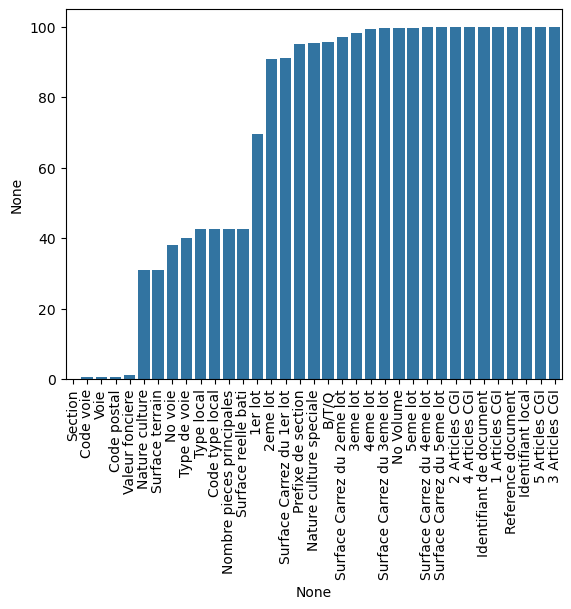

In [8]:
sns.barplot(x=percent_nan.index, y=percent_nan)
plt.xticks(rotation=90)
plt.show()

In [20]:
import pandas as pd

# Copier le df
df_new = df.copy()

# Normaliser les noms de colonnes
df_new.columns = (
    df_new.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("é", "e")
      .str.replace("è", "e")
      .str.replace("à", "a")
)

# Colonnes numériques
df_new['valeur_fonciere'] = pd.to_numeric(df_new['valeur_fonciere'].str.replace(',', '.'), errors='coerce')
df_new['surface_reelle_bati'] = pd.to_numeric(df_new['surface_reelle_bati'], errors='coerce')
df_new['nombre_pieces_principales'] = pd.to_numeric(df_new['nombre_pieces_principales'], errors='coerce')

# Codes postal et commune sur 5 chiffres
df_new['code_postal'] = df_new['code_postal'].apply(lambda x: str(int(x)).zfill(5) if pd.notna(x) else None)

# Filtrer uniquement les types locaux qu'on veut garder
df_new = df_new[df_new['type_local'].isin(['Appartement', 'Maison'])]

# Filtrer uniquement les lignes avec 1 lot
df_new = df_new[(df_new['1er_lot'].notna()) & 
        df_new[['2eme_lot','3eme_lot','4eme_lot','5eme_lot']].isna().all(axis=1)]

# Supprimer les lignes avec NaN sur les colonnes principales
cols_keep = ['date_mutation', 'valeur_fonciere', 'type_local', 
             'surface_reelle_bati', 'nombre_pieces_principales', 'code_postal']
df_new = df_new.dropna(subset=cols_keep)

# Sélection finale des colonnes
df_new = df_new[cols_keep]

df_new.head()

,date_mutation,valeur_fonciere,type_local,surface_reelle_bati,nombre_pieces_principales,code_postal
118,09/01/2024,309700.0,Maison,84.0,4.0,01390
125,05/01/2024,565423.0,Appartement,86.0,3.0,01220
130,10/01/2024,110000.0,Appartement,45.0,2.0,01200
134,02/01/2024,299000.0,Appartement,51.0,3.0,01500
135,02/01/2024,299000.0,Appartement,21.0,1.0,01500


In [21]:
# Copier le df
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222175 entries, 118 to 3489147
Data columns (total 6 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   date_mutation              222175 non-null  object 
 1   valeur_fonciere            222175 non-null  float64
 2   type_local                 222175 non-null  object 
 3   surface_reelle_bati        222175 non-null  float64
 4   nombre_pieces_principales  222175 non-null  float64
 5   code_postal                222175 non-null  object 
dtypes: float64(3), object(3)
memory usage: 11.9+ MB


In [11]:
!pip install category-encoders
!pip install xgboost
!pip install tpot

=== Corrélation avec valeur_fonciere ===
surface_reelle_bati          0.065815
nombre_pieces_principales    0.066805
valeur_fonciere              1.000000
Name: valeur_fonciere, dtype: float64


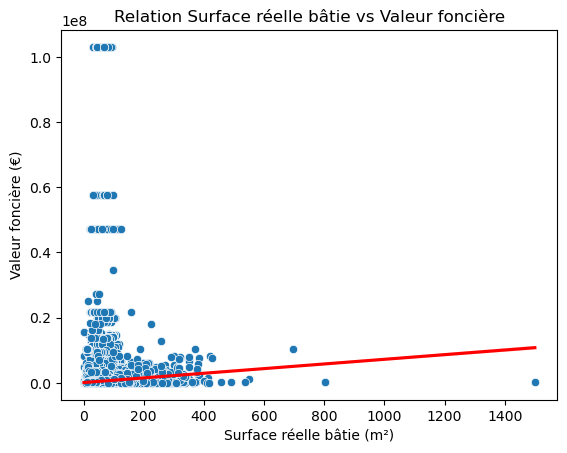

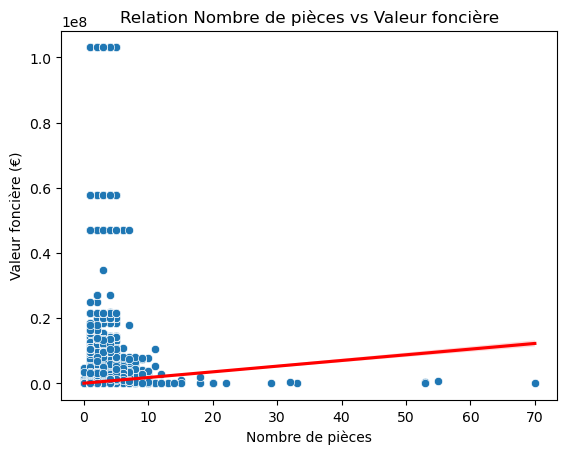

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Corrélation des colonnes numériques avec la target
corrs = df_new.corr(numeric_only=True)['valeur_fonciere'].sort_values()
print("=== Corrélation avec valeur_fonciere ===")
print(corrs)

# Scatter plot + régression pour la surface réelle bâtie
sns.scatterplot(x='surface_reelle_bati', y='valeur_fonciere', data=df_new)
sns.regplot(x='surface_reelle_bati', y='valeur_fonciere', data=df_new,
            scatter=False, color='red')
plt.title("Relation Surface réelle bâtie vs Valeur foncière")
plt.xlabel("Surface réelle bâtie (m²)")
plt.ylabel("Valeur foncière (€)")
plt.show()

# Scatter plot + régression pour le nombre de pièces
sns.scatterplot(x='nombre_pieces_principales', y='valeur_fonciere', data=df_new)
sns.regplot(x='nombre_pieces_principales', y='valeur_fonciere', data=df,
            scatter=False, color='red')
plt.title("Relation Nombre de pièces vs Valeur foncière")
plt.xlabel("Nombre de pièces")
plt.ylabel("Valeur foncière (€)")
plt.show()

In [33]:
df_new.loc[df_new['valeur_fonciere'] > 40000000]

,date_mutation,valeur_fonciere,type_local,surface_reelle_bati,nombre_pieces_principales,code_postal
382602,26/07/2024,47176284.0,Appartement,116.0,5.0,13008
382607,26/07/2024,47176284.0,Appartement,47.0,2.0,13008
382611,26/07/2024,47176284.0,Appartement,72.0,3.0,13008
382612,26/07/2024,47176284.0,Appartement,60.0,3.0,13008
382613,26/07/2024,47176284.0,Appartement,111.0,5.0,13008
...,...,...,...,...,...,...
3289839,25/11/2024,103038040.0,Appartement,90.0,5.0,93140
3289840,25/11/2024,103038040.0,Appartement,81.0,4.0,93140
3290442,25/11/2024,103038040.0,Appartement,67.0,3.0,93140
3290443,25/11/2024,103038040.0,Appartement,67.0,3.0,93140


In [35]:
df.loc[382602]

Identifiant de document                  NaN
Reference document                       NaN
1 Articles CGI                           NaN
2 Articles CGI                           NaN
3 Articles CGI                           NaN
4 Articles CGI                           NaN
5 Articles CGI                           NaN
No disposition                             1
Date mutation                     26/07/2024
Nature mutation                        Vente
Valeur fonciere                  47176284,00
No voie                                  4.0
B/T/Q                                    NaN
Type de voie                             RUE
Code voie                               5364
Voie                              DE LORGUES
Code postal                          13008.0
Commune                       MARSEILLE 8EME
Code departement                          13
Code commune                             208
Prefixe de section                     842.0
Section                                    I
No plan   